# **KNN Benchmarking against the plain prediction**

The aim of this analysis notebook is to determine the real prediction power of proposed model setups. We have earlier analysed <code>MAPE</code> of predictions and we were able to achieve mean deviations ranging from 2 to 8 % against the real value of <code>T+1</code>. 

A more convenient way to track the predicting power is to put model prediction to test against some more simple predictions and verify whether is it any beneficial to develop relatively sophisticated algorithm to predict <code>T+1</code> value fo given stock.

Taking into account large time and space complexity of such analysis on all the given stocks, we have decided to analyse this kind of benchmarking oonly on one given stocks – for these purposes <code>AAPL</code> (Apple Inc.) stock was chosen.

In [1]:
import sys
import os

sys.path.append(os.path.abspath(".."))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from DataFramePrep import generate_TrainingDataFrame

# Metrics to measure successfulness
from sklearn.metrics import mean_absolute_percentage_error, accuracy_score
from sklearn.preprocessing import StandardScaler

# ML Stuff
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier

# **Scaled Benchmarking**

First, we will banchmark the more sophisticated model based on scaled training data.

In [2]:
TrainingDataFrame, tickers, historic_columns, StockDataDatabase = generate_TrainingDataFrame()

In [3]:
performance_tracker = {}
performance_tracker_mean = {}


for ticker in ["AAPL", "MSFT", "IBM", "MU"]:
    Stock_Data = pd.read_sql(f"SELECT * FROM StockData WHERE Ticker='{ticker}' AND Date>='2017-09-14'", con=StockDataDatabase, parse_dates=["Date"])
        
    Stock_Data = pd.merge(Stock_Data, TrainingDataFrame, left_on="Date", right_on="Date")

    Stock_Data["Target"] = Stock_Data["Close"]
    Stock_Data = Stock_Data.dropna().reset_index(drop=True)

    training_length = 30 # Days
    prediction_length = 1 # Days

    performance_tracker[ticker] = []

    MAPEs = []
    performance_mean = []
    for window_start in range(len(Stock_Data) - (training_length + prediction_length)):
        if window_start + training_length + prediction_length > len(TrainingDataFrame):
                continue
            
        scaler = StandardScaler()

        Training_Features = scaler.fit_transform(TrainingDataFrame[historic_columns].iloc[window_start:window_start+training_length])
        Training_Target = Stock_Data["Target"].iloc[window_start:window_start+training_length]
    
        Test_Features = scaler.transform(TrainingDataFrame[historic_columns].iloc[window_start+training_length:window_start+training_length+prediction_length])
        Test_Target = Stock_Data["Target"].iloc[window_start+training_length:window_start+training_length+prediction_length]

        MODEL = KNeighborsRegressor(n_neighbors=3)

        MODEL.fit(Training_Features, Training_Target)
        
        prediction = MODEL.predict(Test_Features)

        MAPEs.append(100*mean_absolute_percentage_error(Test_Target, prediction))
        performance_mean.append(100*mean_absolute_percentage_error(Test_Target, [np.mean(Training_Target.iloc[-1])] ))

        #print(ticker, 100*mean_absolute_percentage_error(Test_Target, prediction), "%")
        
    performance_tracker[ticker] = MAPEs.copy()
    performance_tracker_mean[ticker] = performance_mean.copy()


KeyboardInterrupt: 

With large amount of data, we include only a short sample of data into visualisation.

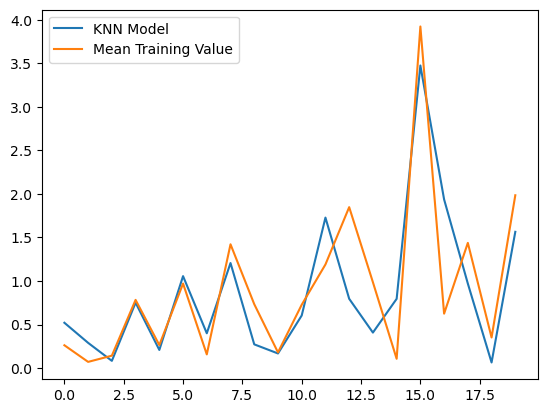

In [34]:
plt.plot(performance_tracker["MSFT"][10:30])
plt.plot(performance_tracker_mean["MSFT"][10:30])

plt.legend(["KNN Model", "Mean Training Value"])

plt.show()

With given setup of <code>training_length</code> & <code>prediction_length</code> we can see superiority of KNN model.

In [35]:
print(np.mean(performance_tracker["AAPL"]))
print(np.mean(performance_tracker_mean["AAPL"]))

1.8908039932225553
1.355310931001411


In [36]:
performance_tracker = {}
performance_tracker_mean = {}


for ticker in ["AAPL", "MSFT", "IBM", "MU"]:
    Stock_Data = pd.read_sql(f"SELECT * FROM StockData WHERE Ticker='{ticker}' AND Date>='2017-09-14'", con=StockDataDatabase, parse_dates=["Date"])
        
    Stock_Data = pd.merge(Stock_Data, TrainingDataFrame, left_on="Date", right_on="Date")

    Stock_Data["Target"] = Stock_Data["Close"]
    Stock_Data = Stock_Data.dropna().reset_index(drop=True)

    training_length = 30 # Days
    prediction_length = 1 # Days

    performance_tracker[ticker] = []

    MAPEs = []
    performance_mean = []
    for window_start in range(len(Stock_Data) - (training_length + prediction_length)):
        Training_Features = Stock_Data[historic_columns].iloc[window_start:window_start+training_length]
        Training_Target = Stock_Data["Target"].iloc[window_start:window_start+training_length]
        
        Test_Features = Stock_Data[historic_columns].iloc[window_start+training_length:window_start+training_length+prediction_length]
        Test_Target = Stock_Data["Target"].iloc[window_start+training_length:window_start+training_length+prediction_length]

        if Test_Features.empty or len(Training_Features) == 0:
            continue

        MODEL = KNeighborsRegressor(n_neighbors=3)

        MODEL.fit(Training_Features, Training_Target)
        
        prediction = MODEL.predict(Test_Features)

        MAPEs.append(100*mean_absolute_percentage_error(Test_Target, prediction))
        performance_mean.append(100*mean_absolute_percentage_error(Test_Target, [np.mean(Training_Target[:-10])] ))

        #print(ticker, 100*mean_absolute_percentage_error(Test_Target, prediction), "%")
        
    performance_tracker[ticker] = MAPEs.copy()
    performance_tracker_mean[ticker] = performance_mean.copy()


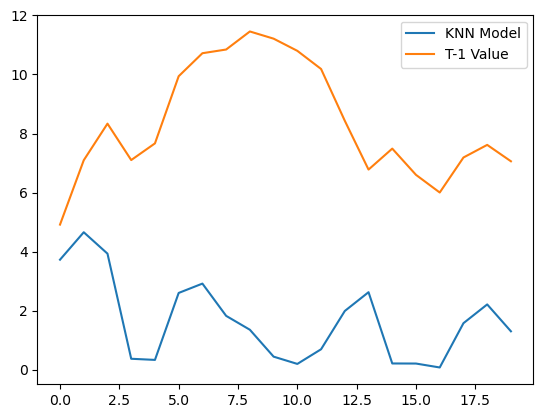

In [37]:
plt.plot(performance_tracker["AAPL"][:20])
plt.plot(performance_tracker_mean["AAPL"][:20])

plt.legend(["KNN Model", "T-1 Value"])

plt.show()

On the other hand, with altered approach to non-modeling prediction we suspect slightly superior performance on given dataset for this approach.

In [38]:
print(np.mean(performance_tracker["AAPL"]))
print(np.mean(performance_tracker_mean["AAPL"]))

1.8908039932225553
6.2771372813445545


# **Non-scaled Benchmarking**

In [39]:
TrainingDataFrame, tickers, historic_columns, StockDataDatabase = generate_TrainingDataFrame()

In [40]:
performance_tracker = {}
performance_tracker_mean = {}


for ticker in ["AAPL", "MSFT", "IBM", "MU"]:
    Stock_Data = pd.read_sql(f"SELECT * FROM StockData WHERE Ticker='{ticker}' AND Date>='2017-09-14'", con=StockDataDatabase, parse_dates=["Date"])
        
    Stock_Data = pd.merge(Stock_Data, TrainingDataFrame, left_on="Date", right_on="Date")

    Stock_Data["Target"] = Stock_Data["Close"]
    Stock_Data = Stock_Data.dropna().reset_index(drop=True)

    training_length = 30 # Days
    prediction_length = 1 # Days

    performance_tracker[ticker] = []

    MAPEs = []
    performance_mean = []
    for window_start in range(len(Stock_Data) - (training_length + prediction_length)):
        Training_Features = Stock_Data[historic_columns].iloc[window_start:window_start+training_length]
        Training_Target = Stock_Data["Target"].iloc[window_start:window_start+training_length]
        
        Test_Features = Stock_Data[historic_columns].iloc[window_start+training_length:window_start+training_length+prediction_length]
        Test_Target = Stock_Data["Target"].iloc[window_start+training_length:window_start+training_length+prediction_length]

        if Test_Features.empty or len(Training_Features) == 0:
            continue

        MODEL = KNeighborsRegressor(n_neighbors=3)

        MODEL.fit(Training_Features, Training_Target)
        
        prediction = MODEL.predict(Test_Features)

        MAPEs.append(100*mean_absolute_percentage_error(Test_Target, prediction))
        performance_mean.append(100*mean_absolute_percentage_error(Test_Target, [np.mean(Training_Target.iloc[-1])] ))

        #print(ticker, 100*mean_absolute_percentage_error(Test_Target, prediction), "%")
        
    performance_tracker[ticker] = MAPEs.copy()
    performance_tracker_mean[ticker] = performance_mean.copy()


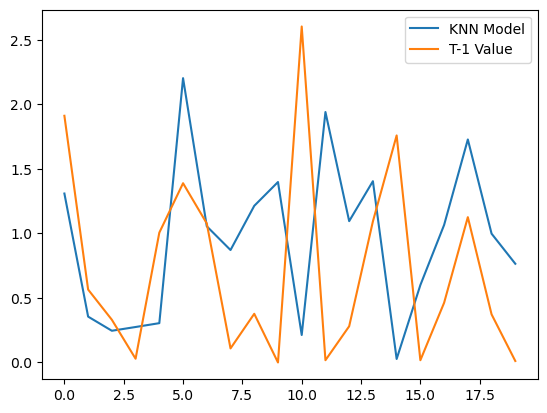

In [41]:
plt.plot(performance_tracker["AAPL"][30:50])
plt.plot(performance_tracker_mean["AAPL"][30:50])

plt.legend(["KNN Model", "T-1 Value"])

plt.show()

Similarly, even this time we analyse similar results as above, in **scaled** training of the model.

In [42]:
print(np.mean(performance_tracker["AAPL"]))
print(np.mean(performance_tracker_mean["AAPL"]))

3.8795826897604746
1.355310931001411


In [43]:
performance_tracker = {}
performance_tracker_mean = {}


for ticker in ["AAPL", "MSFT", "IBM", "MU"]:
    Stock_Data = pd.read_sql(f"SELECT * FROM StockData WHERE Ticker='{ticker}' AND Date>='2017-09-14'", con=StockDataDatabase, parse_dates=["Date"])
        
    Stock_Data = pd.merge(Stock_Data, TrainingDataFrame, left_on="Date", right_on="Date")

    Stock_Data["Target"] = Stock_Data["Close"]
    Stock_Data = Stock_Data.dropna().reset_index(drop=True)

    training_length = 30 # Days
    prediction_length = 1 # Days

    performance_tracker[ticker] = []

    MAPEs = []
    performance_mean = []
    for window_start in range(len(Stock_Data) - (training_length + prediction_length)):
        Training_Features = Stock_Data[historic_columns].iloc[window_start:window_start+training_length]
        Training_Target = Stock_Data["Target"].iloc[window_start:window_start+training_length]
        
        Test_Features = Stock_Data[historic_columns].iloc[window_start+training_length:window_start+training_length+prediction_length]
        Test_Target = Stock_Data["Target"].iloc[window_start+training_length:window_start+training_length+prediction_length]

        if Test_Features.empty or len(Training_Features) == 0:
            continue

        MODEL = KNeighborsRegressor(n_neighbors=3)

        MODEL.fit(Training_Features, Training_Target)
        
        prediction = MODEL.predict(Test_Features)

        MAPEs.append(100*mean_absolute_percentage_error(Test_Target, prediction))
        performance_mean.append(100*mean_absolute_percentage_error(Test_Target, [np.mean(Training_Target.iloc[-1])] ))

        #print(ticker, 100*mean_absolute_percentage_error(Test_Target, prediction), "%")
        
    performance_tracker[ticker] = MAPEs.copy()
    performance_tracker_mean[ticker] = performance_mean.copy()


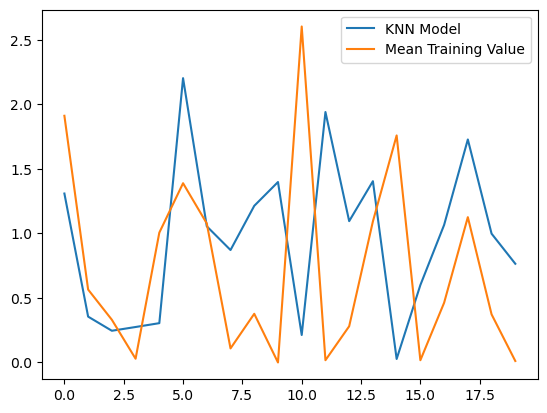

In [44]:
plt.plot(performance_tracker["AAPL"][30:50])
plt.plot(performance_tracker_mean["AAPL"][30:50])

plt.legend(["KNN Model", "Mean Training Value"])

plt.show()

In [46]:
print(np.mean(performance_tracker["AAPL"]))
print(np.mean(performance_tracker_mean["AAPL"]))

3.8795826897604746
1.355310931001411
